In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/projects/Data analysis/Suicides_in_india/suicides_in_india_cleaned_data.csv')

In [ ]:
data_by_causes=data[data['type_code']=='Causes']
data_by_Professional_Profile=data[data['type_code']=='Professional_Profile']
data_by_Means_adopted=data[data['type_code']=='Means_adopted']


In [49]:
data_by_causes=data_by_causes.replace('Not having Children(Barrenness/Impotency','Not having Children (Barrenness/Impotency').replace('Not having Children (Barrenness/Impotency','Not having Children (Barrenness/Impotency)')

In [81]:
data_by_Means_adopted=data_by_Means_adopted.replace('By Other means','By Other means (please specify)')

In [51]:
plt.style.use('classic')

##1. What is the main cause for suicides?(national)

In [52]:
data_by_causes.groupby('type')['total'].sum().sort_values(ascending=False)#.head(1)

,total
type,
Family Problems,341952
Causes Not known,237069
Other Causes (Please Specity),216050
Other Prolonged Illness,194565
Insanity/Mental Illness,94229
Love Affairs,45039
Bankruptcy or Sudden change in Economic,32755
Poverty,32684
Dowry Dispute,31970


##2. What is main cause for suicides by state, age_group, gender, professional status?

### main causes for suicides by state.

In [53]:
state_wise_causes_data=data_by_causes.groupby(['state','type'])['total'].sum().unstack()
state_wise_causes_data.idxmax(axis=1).to_frame().rename(columns={0:'main cause'})

,main cause
state,
A & N Islands,Other Causes (Please Specity)
Andhra Pradesh,Other Prolonged Illness
Arunachal Pradesh,Causes Not known
Assam,Causes Not known
Bihar,Other Causes (Please Specity)
Chandigarh,Family Problems
Chhattisgarh,Causes Not known
D & N Haveli,Family Problems
Daman & Diu,Causes Not known


### main causes for suicides by age_group.

In [54]:
age_group_wise_causes_data=data_by_causes.groupby(['type','age_group'])['total'].sum().unstack(level=0)
age_group_wise_causes_data.idxmax(axis=1).to_frame().rename(columns={0:'main cause'})

,main cause
age_group,
0-14,Other Causes (Please Specity)
15-29,Family Problems
30-44,Family Problems
45-59,Family Problems
60+,Other Prolonged Illness


### main causes for suicides by gender.

In [55]:
gender_wise_causes_data=data_by_causes.groupby(['type','gender'])['total'].sum().unstack()
gender_wise_causes_data.idxmax().to_frame().rename(columns={0:'main cause'})

,main cause
gender,
Female,Family Problems
Male,Family Problems


### main causes for suicides by gender+age_group.

In [59]:
gender_and_age_group_and_causes_wise_data=data_by_causes.groupby(['type','age_group','gender'])['total'].sum().unstack().unstack()

gender_and_age_group_and_causes_wise_data.idxmax().to_frame().rename(columns={0:'main cause'})

main cause
gender age_group                               
Female 0-14       Other Causes (Please Specity)
       15-29                    Family Problems
       30-44                    Family Problems
       45-59                    Family Problems
       60+              Other Prolonged Illness
Male   0-14       Other Causes (Please Specity)
       15-29                    Family Problems
       30-44                    Family Problems
       45-59                    Family Problems
       60+              Other Prolonged Illness

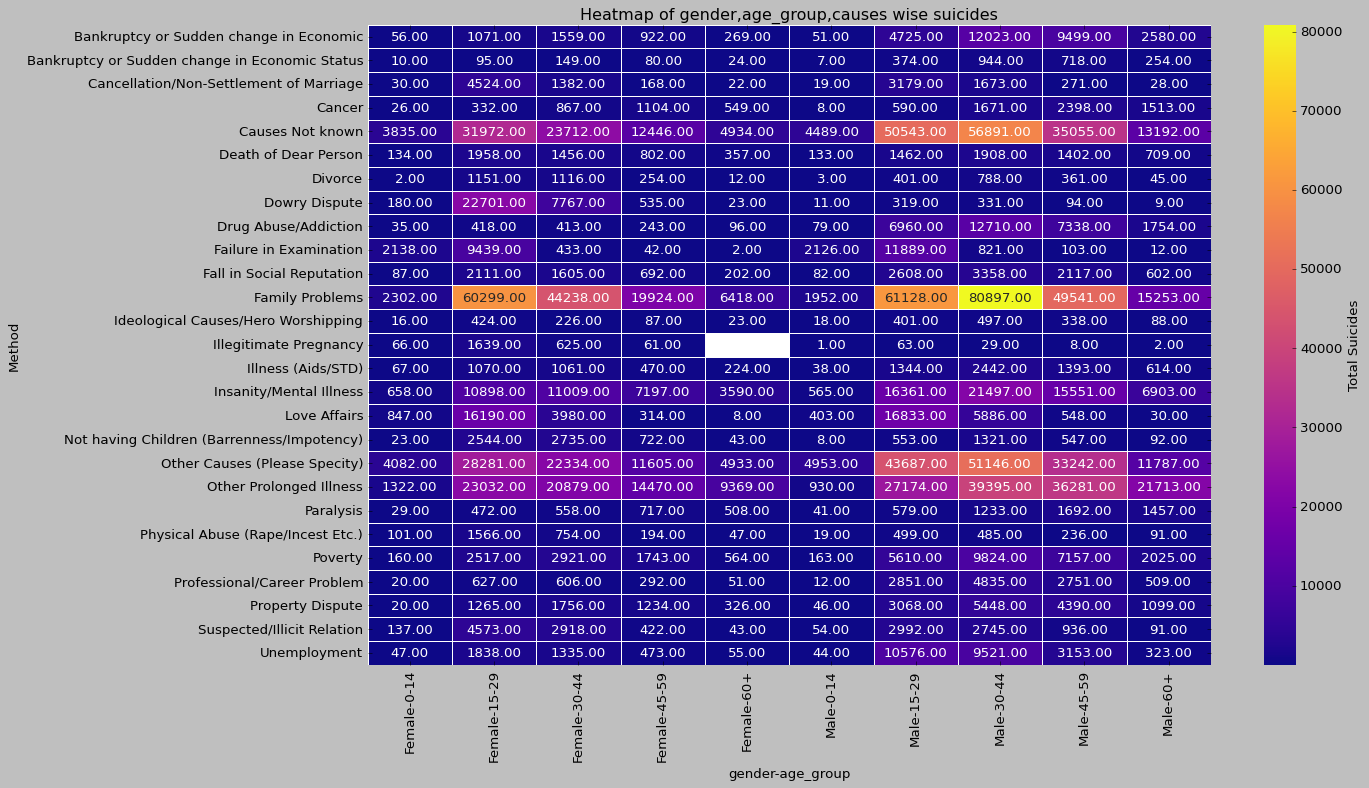

In [77]:
plt.figure(figsize=(17,10))
sns.heatmap(gender_and_age_group_and_causes_wise_data,cmap='plasma',linewidths=0.5,annot=True,fmt='0.2f').collections[0].colorbar.set_label('Total Suicides')
plt.title('Heatmap of gender,age_group,causes wise suicides')
plt.ylabel('Method')
plt.show()

##3. What is main means_adopted for suicides?(national)

In [83]:
data_by_Means_adopted.groupby('type')['total'].sum().sort_values(ascending=False).head(1)

,total
type,
By Hanging,460955


##4.  What is main method for suicides by state, age_group, gender, professional status?

### main method for suicides by state.


In [93]:
data_by_Means_adopted.groupby(['state','type'])['total'].sum().unstack().idxmax(axis=1).to_frame().rename(columns={0:'main method'})

,main method
state,
A & N Islands,By Hanging
Andhra Pradesh,By Consuming Insecticides
Arunachal Pradesh,By Hanging
Assam,By Hanging
Bihar,By Other means (please specify)
Chandigarh,By Hanging
Chhattisgarh,By Hanging
D & N Haveli,By Hanging
Daman & Diu,By Hanging


### main method for suicides by age_group.


In [94]:
data_by_Means_adopted.groupby(['age_group','type'])['total'].sum().unstack().idxmax(axis=1).to_frame().rename(columns={0:'main method'})

,main method
age_group,
0-14,By Hanging
15-29,By Hanging
30-44,By Hanging
45-59,By Hanging
60+,By Hanging


### main method for suicides by gender.


In [105]:
data_by_Means_adopted.groupby(['type','gender'])['total'].sum().unstack().idxmax(axis=0).to_frame().rename(columns={0:'main method'})

,main method
gender,
Female,By Hanging
Male,By Hanging


### main method for suicides by gender+age_group.

In [106]:
data_by_Means_adopted.groupby(['type','gender','age_group'])['total'].sum().unstack().idxmax(axis=0).to_frame().rename(columns={0:'main method'})

,main method
age_group,
0-14,"(By Other means (please specify), Male)"
15-29,"(By Hanging, Male)"
30-44,"(By Hanging, Male)"
45-59,"(By Hanging, Male)"
60+,"(By Hanging, Male)"
